# LACT / simtelarray 事件检查

这个 notebook 按物理流程检查一个事件：读取事件、准备 raw image、图像清理、Hillas 参数、方向/芯位重建、SDP 平面图。

不同输入格式只在第一个配置 cell 里切换；读出来以后，后面的分析和画图步骤保持一致。

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/home/lhaaso/huangyiyun/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

LACT_ROOT_FILE = Path("/home/lhaaso/huangyiyun/LACT/Sim_program/LACT_sim/run_logs/lact_root_only_full_response/lact_events.root")
if not LACT_ROOT_FILE.exists():
    LACT_ROOT_FILE = Path("/home/lhaaso/huangyiyun/LACT/Sim_program/LACT_sim/run_logs/lact_root_full_response/lact_events.root")

SIMTEL_FILE = Path("/eos/lhaaso/simulation/lactmc/prod1/point_gamma/simtel/zenith_20/azimuth_0/100GeV_1000GeV/run000001/lact_prod1_simtel_particle_gamma_energy_100.0_1000.0_zenith_20.0_azimuth_0.0_run_1_event_0.zst")


# 只改这里即可："lact_root" / "simtel" / "root_event"
INPUT_KIND = "lact_root"
INPUT_FILE = LACT_ROOT_FILE
# INPUT_KIND = "simtel"
# INPUT_FILE = SIMTEL_FILE
# INPUT_KIND = "root_event"; INPUT_FILE = ROOT_EVENT_FILE

EVENT_INDEX = 5
MAX_EVENTS = 15

print("input kind:", INPUT_KIND)
print("input file:", INPUT_FILE)
print("exists:", INPUT_FILE.exists())


input kind: lact_root
input file: /home/lhaaso/huangyiyun/LACT/Sim_program/LACT_sim/run_logs/lact_root_only_full_response/lact_events.root
exists: True


In [2]:
import time
import numpy as np
from IPython.display import display

try:
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
except Exception:
    pio = None

from pylast.io import LactEventSource, SimtelEventSource, RootEventSource
from pylast.calib import Calibrator
from pylast.image import ImageProcessor
from pylast.reco import ShowerProcessor
from pylast.visualize import (
    EventVisualizer,
    hillas_parameter_rows,
    plot_clean_images,
    plot_event_cameras,
    plot_event_cores,
    plot_event_sdp_planes,
    plot_event_sdp_planes_3d,
    plot_event_sdp_planes_3d_interactive,
    plot_raw_images,
    reconstruction_summary,
)


CALIBRATOR_CONFIG = """{
  "Calibrator": {
    "image_extractor_type": "LocalPeakExtractor",
    "LocalPeakExtractor": {
      "window_width": 7,
      "window_shift": 3,
      "apply_correction": false
    }
  }
}
"""

IMAGE_PROCESSOR_CONFIG = """{
  "poisson_noise": 0.0
}
"""

SHOWER_PROCESS_CONFIG = """{
  "ShowerProcessor": {
    "GeometryReconstructionTypes": ["HillasReconstructor"],
    "HillasReconstructor": {
      "use_fake_hillas": false,
      "ImageQuery": "hillas_intensity > 100 && leakage_intensity_width_2 < 0.3"
    }
  }
}
"""


def step(name, fn):
    print(f"BEGIN {name}", flush=True)
    t0 = time.perf_counter()
    out = fn()
    print(f"END {name}: {time.perf_counter() - t0:.3f}s", flush=True)
    return out


def read_one_event(kind, filename, event_index=0, max_events=10):
    filename = str(filename)
    if kind == "lact_root":
        source_data = LactEventSource(filename, max_events=max_events)
        event = source_data[event_index]
    elif kind == "simtel":
        source_data = SimtelEventSource(filename, max_events=max(max_events, event_index + 1))
        event = list(source_data)[event_index]
    elif kind == "root_event":
        source_data = RootEventSource(filename, max_events=max_events)
        event = source_data[event_index]
    else:
        raise ValueError("INPUT_KIND must be lact_root, simtel, or root_event")
    return source_data, event, EventVisualizer(source_data)


def build_processors(source_data):
    calibrator = Calibrator(source_data.subarray, config_str=CALIBRATOR_CONFIG)
    image_processor = ImageProcessor(source_data.subarray, config_str=IMAGE_PROCESSOR_CONFIG)
    shower_processor = ShowerProcessor(source_data.subarray, config_str=SHOWER_PROCESS_CONFIG)
    return calibrator, image_processor, shower_processor


def prepare_raw_image(event, calibrator):
    if getattr(event, "dl0", None) is None:
        step("抽取 raw image", lambda: calibrator(event))
    return event


def print_event_summary(event):
    shower = event.simulation.shower
    print("event_id:", event.event_id)
    print("run_id:", event.run_id)
    print("energy [TeV]:", float(shower.energy))
    print("true zenith [deg]:", 90.0 - np.degrees(float(shower.alt)))
    print("true azimuth [deg]:", np.degrees(float(shower.az)))
    print("true core [m]:", float(shower.core_x), float(shower.core_y))


## 1. 读取事件

这里读入一种格式。后面的 cell 不再区分输入来自 LACT ROOT、simtelarray，还是 pylast 原生 ROOT。

In [3]:
source_data, event, visualizer = step(
    "读取事件",
    lambda: read_one_event(INPUT_KIND, INPUT_FILE, EVENT_INDEX, MAX_EVENTS),
)

print("subarray", len(source_data.subarray.tels), flush=True)

print("calibrator", flush=True)
calibrator = Calibrator(source_data.subarray, config_str=CALIBRATOR_CONFIG)

print("image_processor", flush=True)
image_processor = ImageProcessor(source_data.subarray, config_str=IMAGE_PROCESSOR_CONFIG)

print("shower_processor", flush=True)
shower_processor = ShowerProcessor(source_data.subarray, config_str=SHOWER_PROCESS_CONFIG)

print("done", flush=True)

BEGIN 读取事件
END 读取事件: 1.989s
subarray 32
calibrator
image_processor
shower_processor
image_cleaner_type: Tailcuts_cleaner
done
[2026-06-17 15:51:17.087] [info] Checking if geometry reconstruction type HillasReconstructor is registered


In [4]:
print("after processors", flush=True)
print("has dl0:", getattr(event, "dl0", None) is not None, flush=True)
print("has r1:", getattr(event, "r1", None) is not None, flush=True)
print("dl0 tels:", len(event.dl0.tels) if getattr(event, "dl0", None) else None, flush=True)
print("r1 tels:", len(event.r1.tels) if getattr(event, "r1", None) else None, flush=True)

print("before prepare_raw_image", flush=True)
prepare_raw_image(event, calibrator)
print("after prepare_raw_image", flush=True)

print("before summary", flush=True)
print_event_summary(event)
print("after summary", flush=True)

after processors
has dl0: False
has r1: True
dl0 tels: None
r1 tels: 4
before prepare_raw_image
BEGIN 抽取 raw image
END 抽取 raw image: 0.000s
after prepare_raw_image
before summary
event_id: 606
run_id: 0
energy [TeV]: 0.730666748046875
true zenith [deg]: 19.999999418185837
true azimuth [deg]: 8.65142200549467e-06
true core [m]: -430.57089843750003 249.29099609375
after summary


In [5]:
# source_data, event, visualizer = step(
#     "读取事件",
#     lambda: read_one_event(INPUT_KIND, INPUT_FILE, EVENT_INDEX, MAX_EVENTS),
# )
# calibrator, image_processor, shower_processor = build_processors(source_data)
# prepare_raw_image(event, calibrator)
# print_event_summary(event)


## 2. 望远镜分布、芯位和 SDP 投影

这里画阵列背景、真实芯位、触发望远镜，以及 SDP 平面在地面的投影。

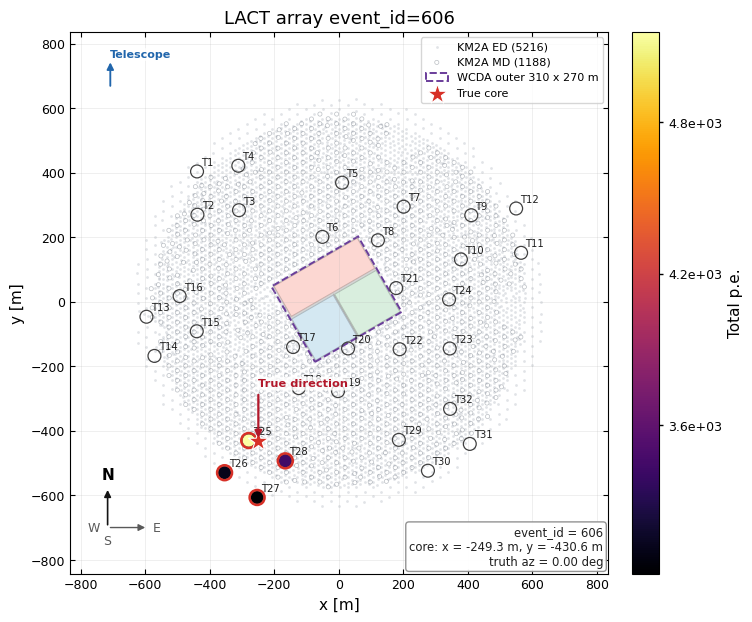

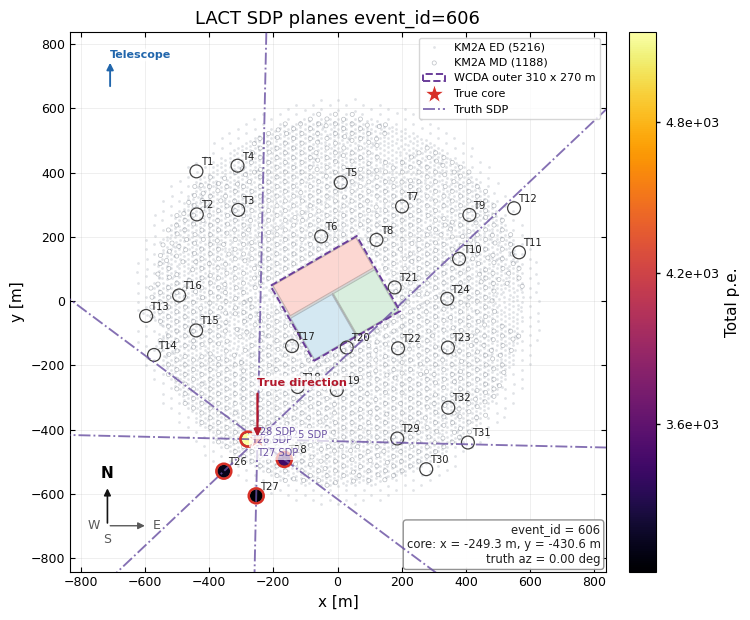

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 760x700 with 2 Axes>,
 'axis': <Axes: title={'center': 'LACT SDP planes event_id=606'}, xlabel='x [m]', ylabel='y [m]'>,
 'path': None}

In [6]:
plot_event_cores(event, visualizer=visualizer, include_non_triggered=False)


plot_event_sdp_planes(event, visualizer=visualizer, include_non_triggered=False)



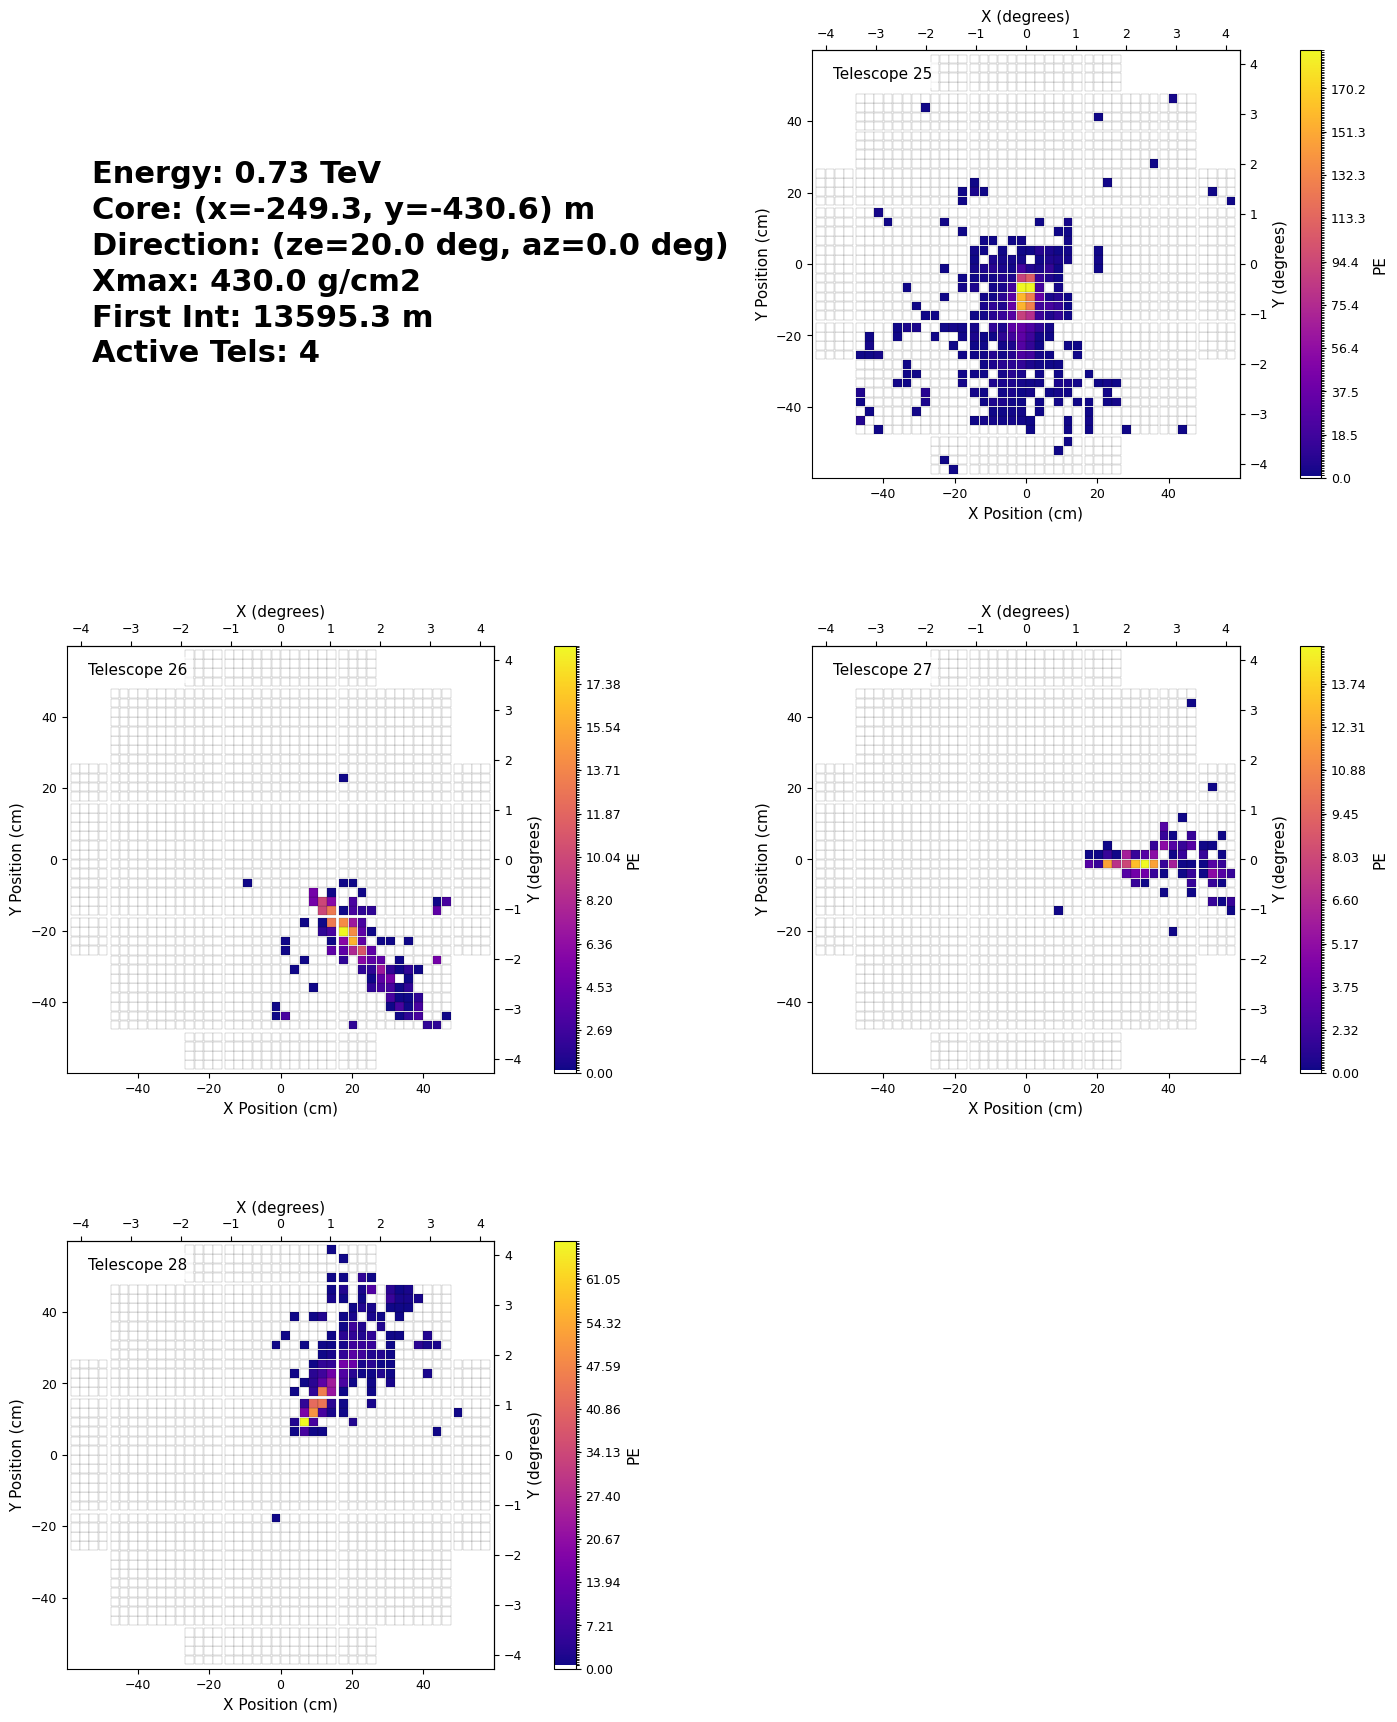

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 1400x1800 with 10 Axes>,
 'axes': array([<Axes: >,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: >], dtype=object),
 'path': None}

In [7]:
plot_event_cameras(
    event,
    visualizer=visualizer,
    image_level="simulation",
    include_non_triggered=False,
)

## 3. Raw image

这里画清理前的相机图像。对 LACT ROOT，这是输出里的积分 p.e.；对 simtelarray，这是从 waveform 抽取出的积分图像。

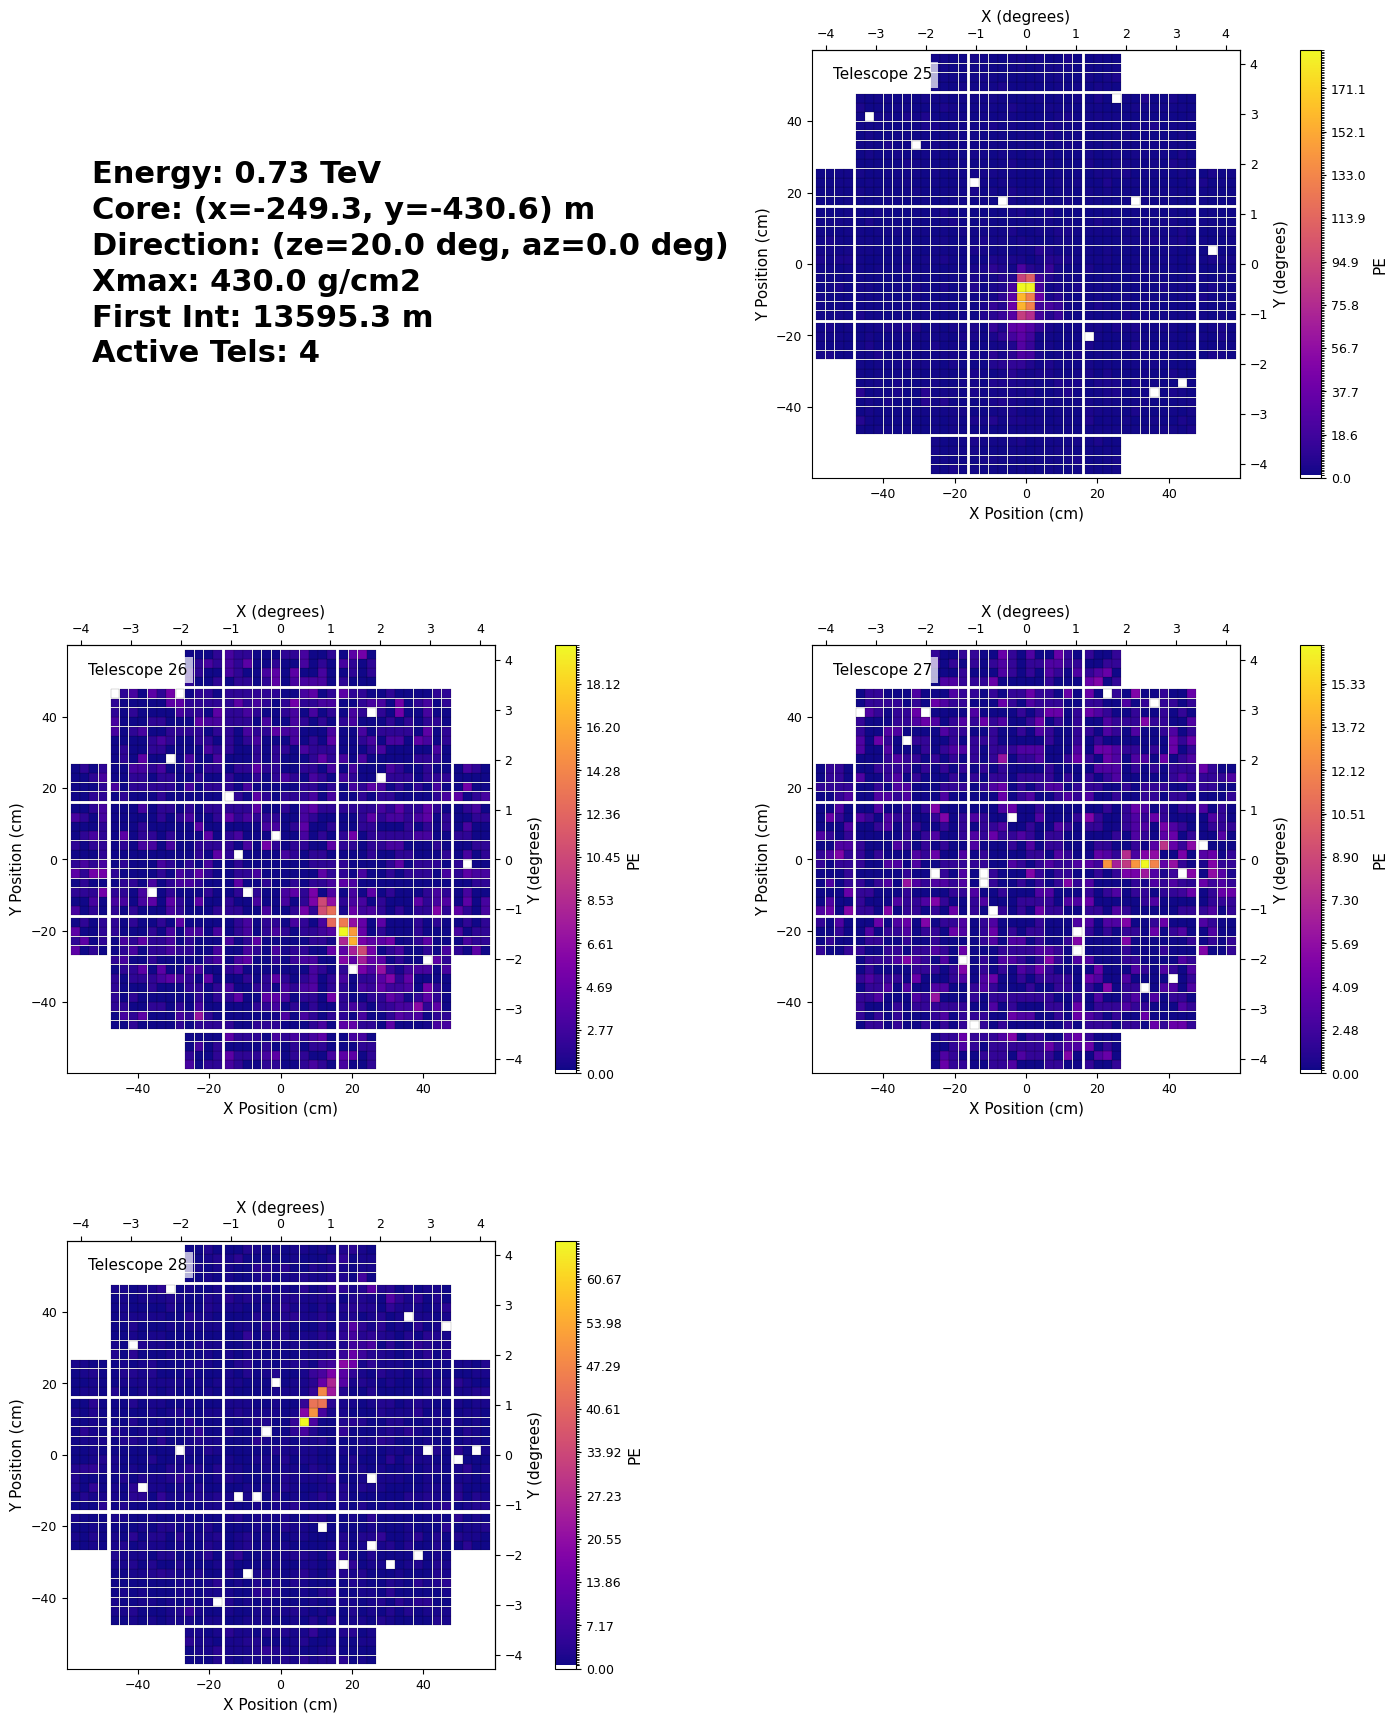

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 1400x1800 with 10 Axes>,
 'axes': array([<Axes: >,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: >], dtype=object),
 'path': None}

In [8]:
plot_raw_images(event, visualizer=visualizer, include_non_triggered=False)

## 4. Clean image 和 Hillas 参数

这里运行图像清理，并画清理后的图像和 Hillas 椭圆。

In [9]:
step("图像清理 + Hillas 参数", lambda: image_processor(event))

rows = hillas_parameter_rows(event)
print("有 Hillas 参数的望远镜:", [row["tel_id"] for row in rows])
for row in rows:
    print(
        f"Tel {row['tel_id']:2d}: intensity={row['intensity']:.2f}, "
        f"length={row['length_rad']:.5g} rad, width={row['width_rad']:.5g} rad, "
        f"psi={np.degrees(row['psi_rad']):.2f} deg"
    )

# plot_clean_images(event, visualizer=visualizer, show_hillas=True, include_non_triggered=False,ideal=True)



BEGIN 图像清理 + Hillas 参数
END 图像清理 + Hillas 参数: 0.001s
有 Hillas 参数的望远镜: [24, 25, 26, 27]
Tel 24: intensity=2106.51, length=0.0074974 rad, width=0.0037347 rad, psi=81.61 deg
Tel 25: intensity=168.21, length=0.0072979 rad, width=0.0016856 rad, psi=-50.07 deg
Tel 26: intensity=58.66, length=0.0024042 rad, width=0.0016345 rad, psi=19.06 deg
Tel 27: intensity=516.87, length=0.0092994 rad, width=0.0020237 rad, psi=55.21 deg


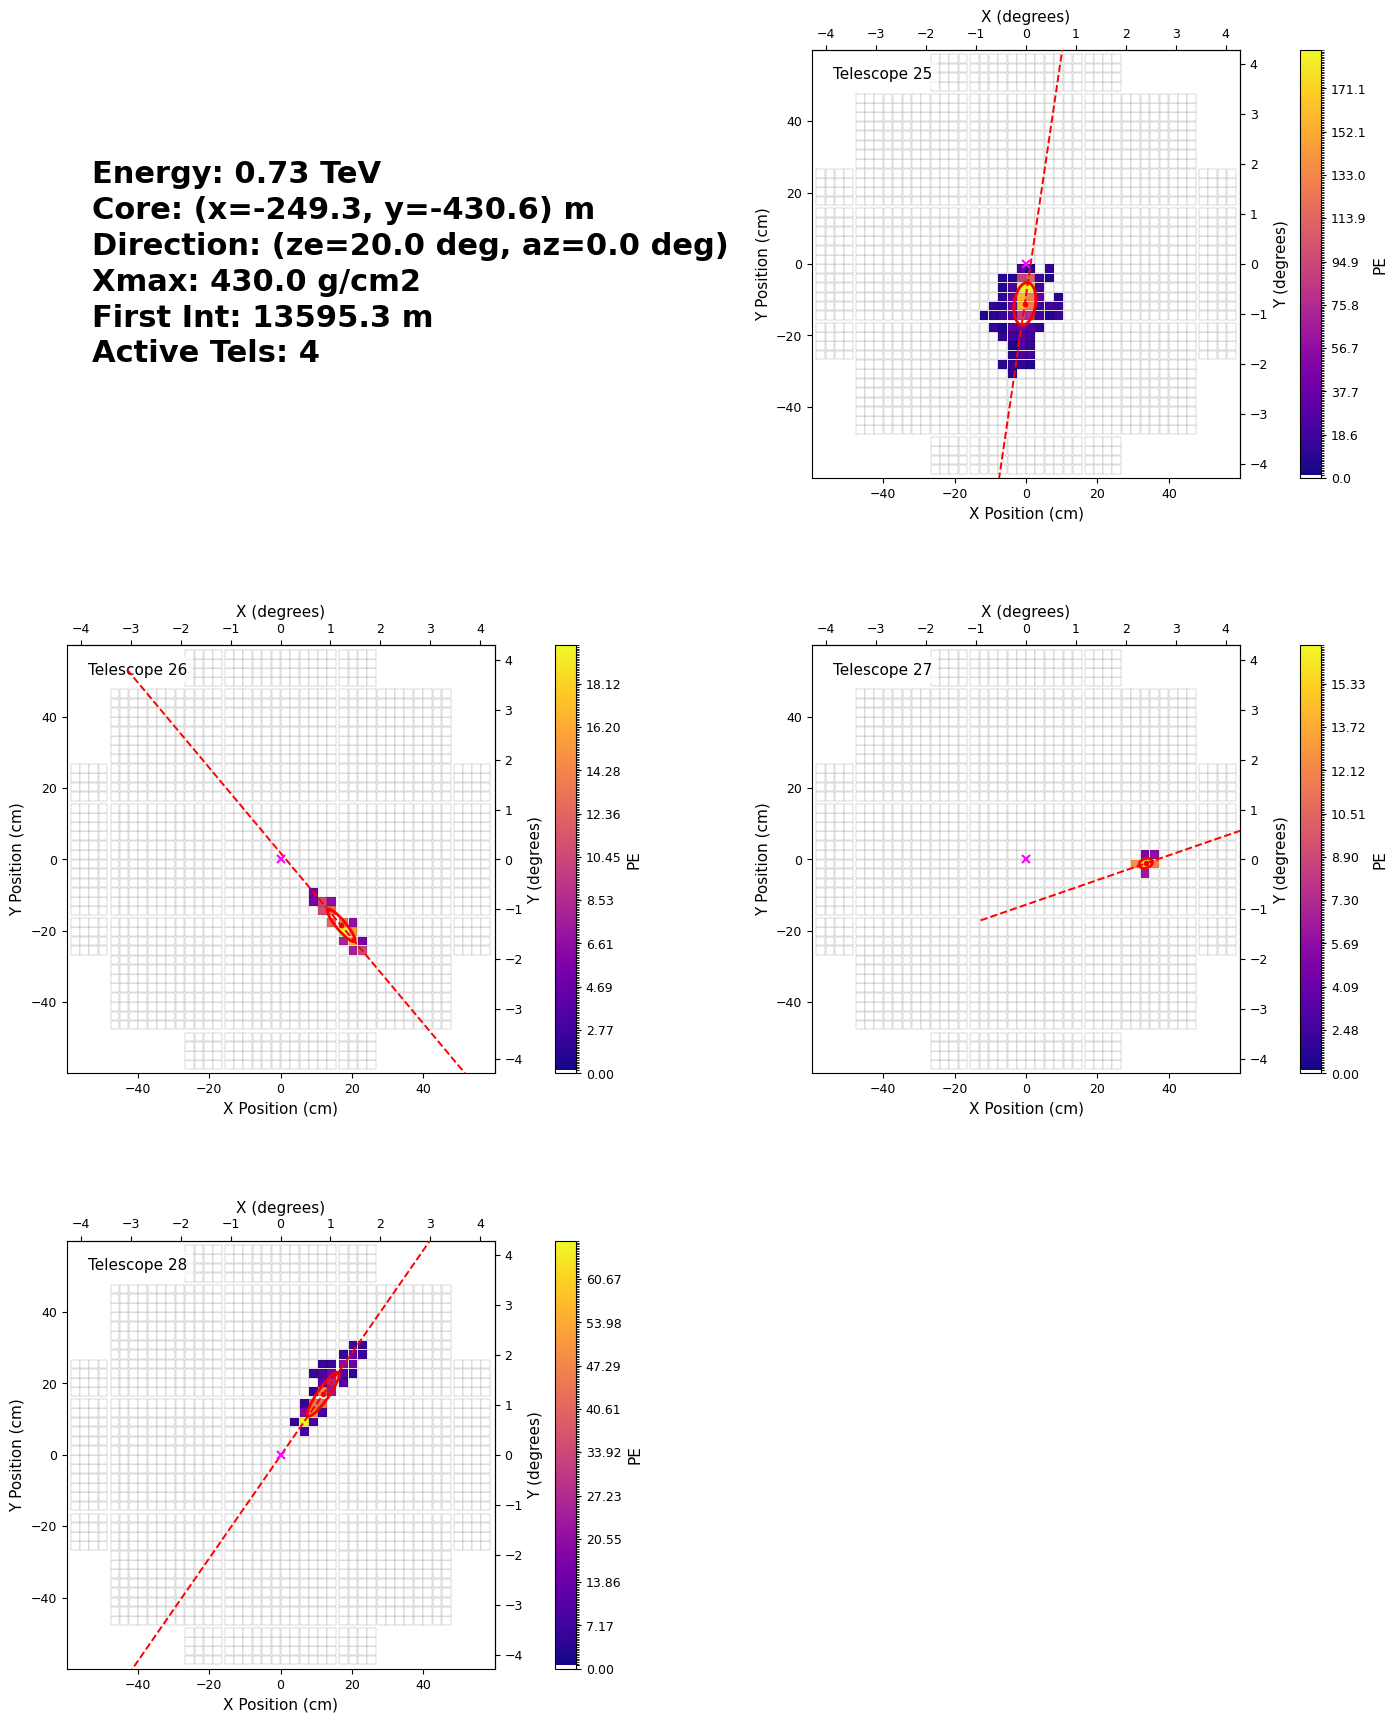

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available
   DL1 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 1400x1800 with 10 Axes>,
 'axes': array([<Axes: >,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: >], dtype=object),
 'path': None}

In [10]:
plot_clean_images(
    event,
    visualizer=visualizer,
    show_hillas=True,
    include_non_triggered=False,
    ideal=True,
)

## 5. 方向和芯位重建

这里用 pylast 的 Hillas 重建。若 `is_valid=False`，通常说明通过筛选的望远镜不够或图像质量条件太严。

In [11]:
step("方向/芯位重建", lambda: shower_processor(event))
summary = reconstruction_summary(event, "HillasReconstructor")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6g}")
    else:
        print(f"{key}: {value}")


BEGIN 方向/芯位重建
END 方向/芯位重建: 0.000s
event_id: 606
reconstructor: HillasReconstructor
is_valid: True
n_hillas_telescopes: 4
true_alt_deg: 70
true_az_deg: 8.65142e-06
true_zenith_deg: 20
true_core_x_m: -430.571
true_core_y_m: 249.291
reco_alt_deg: 70.0791
reco_az_deg: 0.209997
reco_zenith_deg: 19.9209
reco_core_x_m: -435.072
reco_core_y_m: 246.018
direction_error_deg: 0.106716
truth_reco_sep_deg: 0.106716


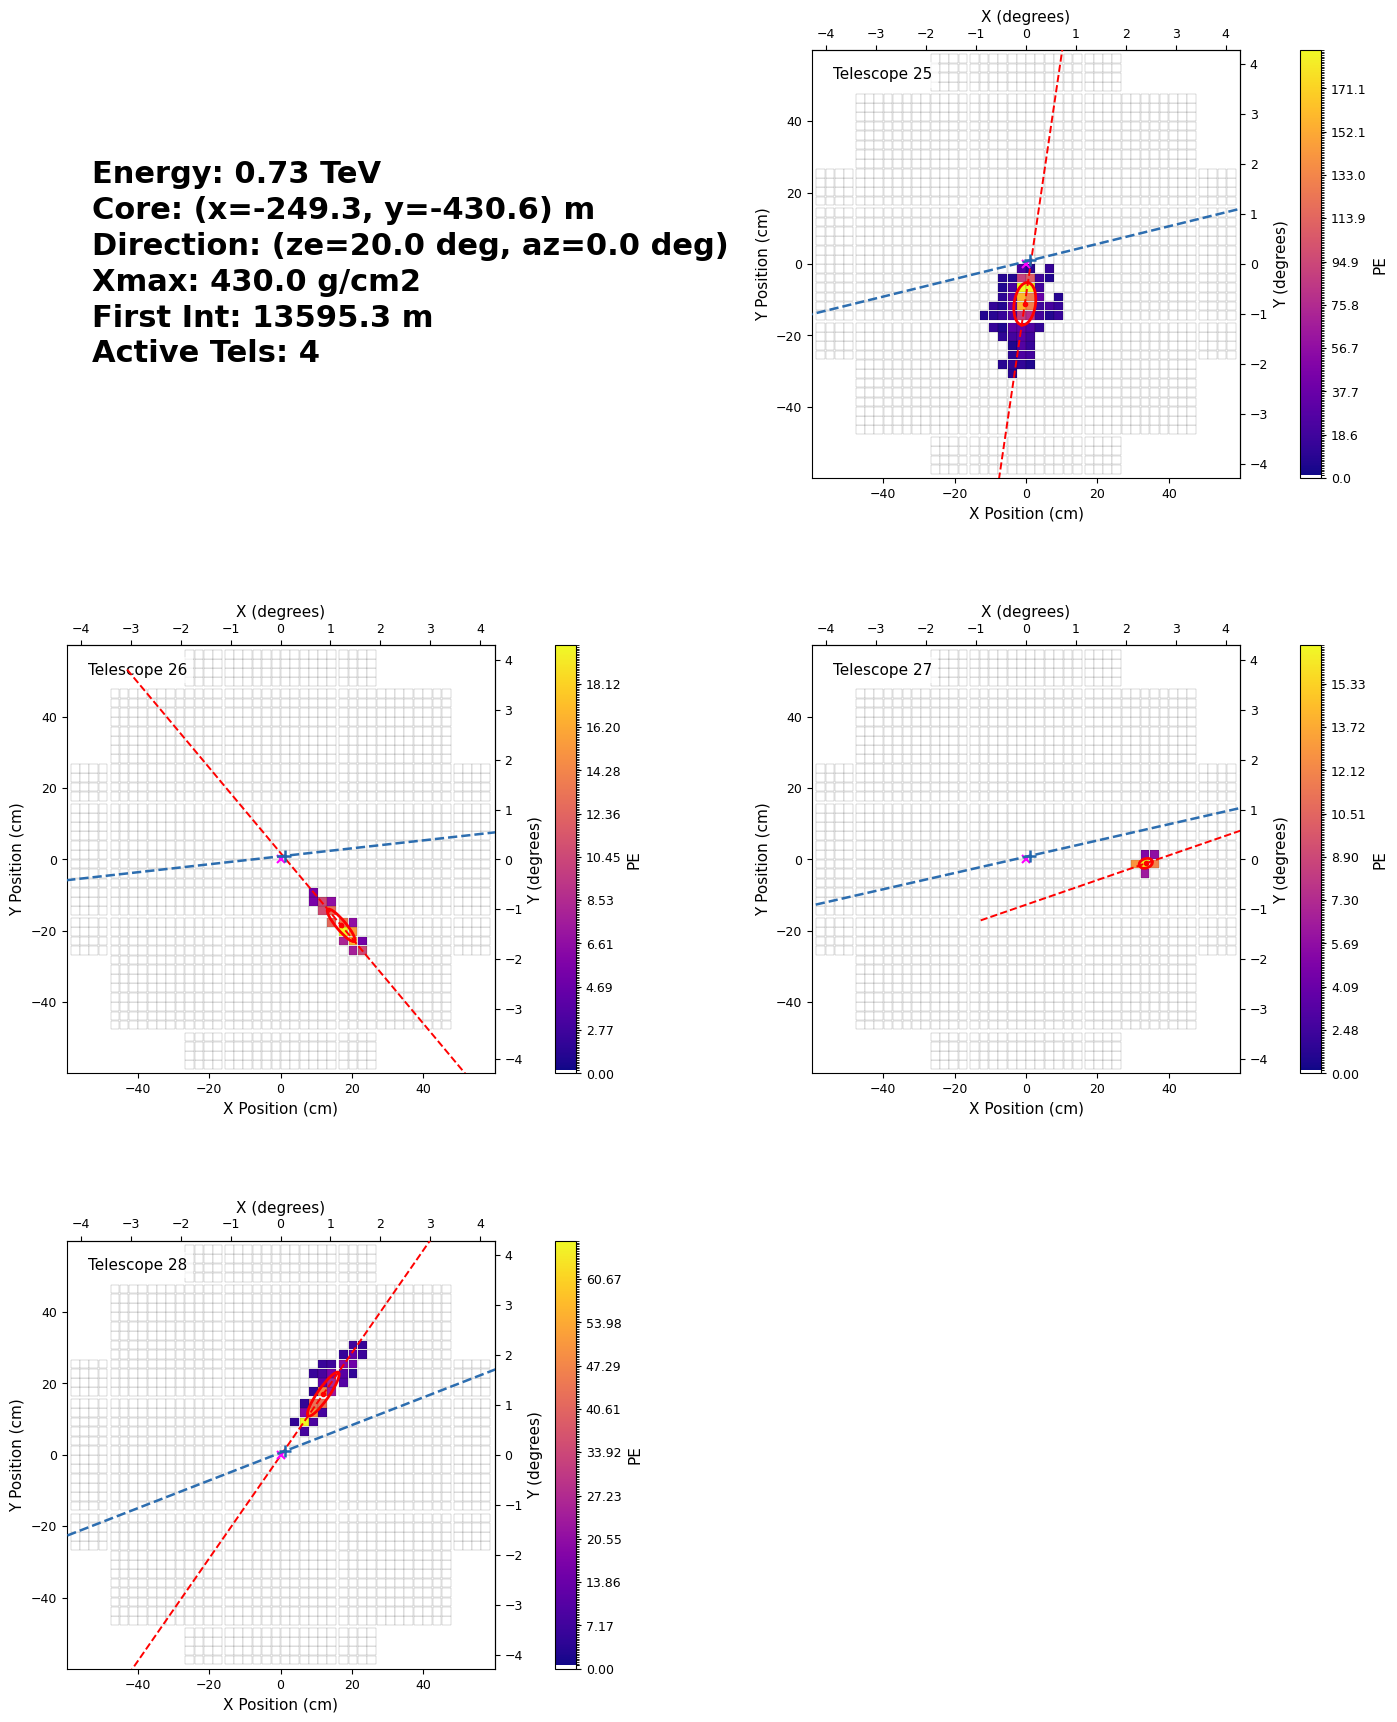

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available
   DL1 Data: Available
   DL2 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 1400x1800 with 10 Axes>,
 'axes': array([<Axes: >,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: xlabel='X Position (cm)', ylabel='Y Position (cm)'>,
        <Axes: >], dtype=object),
 'path': None}

In [12]:
plot_clean_images(
    event,
    visualizer=visualizer,
    show_hillas=True,
    include_non_triggered=False,
    ideal=True,
    reco=True,
)

## 6. 3D SDP 平面

这里在重建之后画 3D SDP。默认先画 Plotly 交互图，可以在 notebook 或导出的 HTML 里旋转、缩放；红色是真实芯位和真实方向，蓝色是重建芯位和重建方向。

In [13]:
plot_event_sdp_planes_3d_interactive(
    event,
    visualizer=visualizer,
    include_non_triggered=False,
    z_max=1200.0,
    show_reco=True,
)


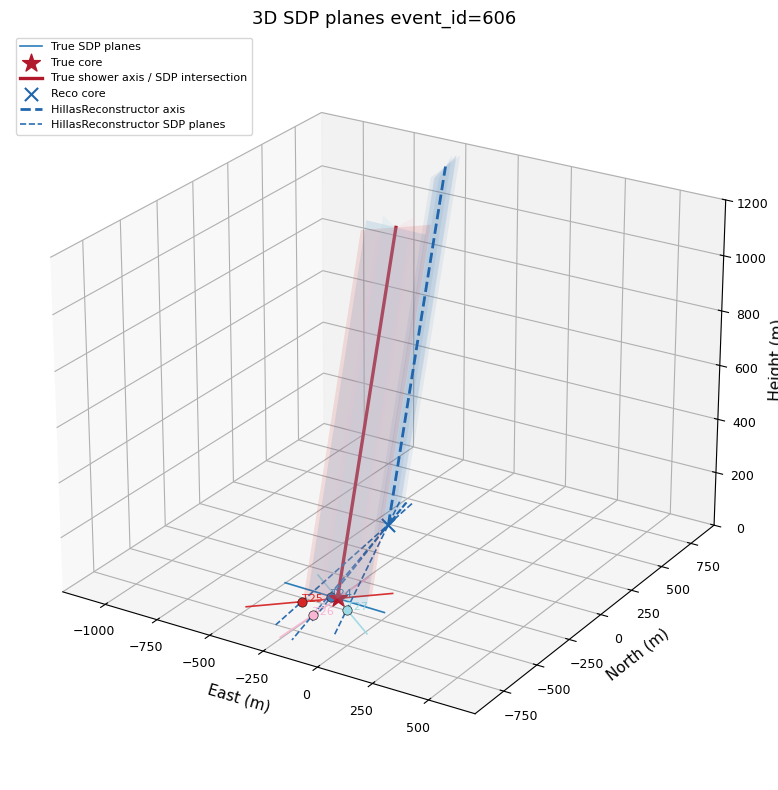

{'event': ArrayEvent:
   Simulation: Available
   R0 Data: Available
   R1 Data: Available
   DL0 Data: Available
   DL1 Data: Available
   DL2 Data: Available,
 'visualizer': <pylast.visualize.event_visualizer.EventVisualizer at 0x14a4d16f5590>,
 'figure': <Figure size 1100x800 with 1 Axes>,
 'axis': <Axes3D: title={'center': '3D SDP planes event_id=606'}, xlabel='East (m)', ylabel='North (m)', zlabel='Height (m)'>,
 'path': None}

In [14]:
# 静态版本用于保存 PNG 或快速预览。
plot_event_sdp_planes_3d(
    event,
    visualizer=visualizer,
    include_non_triggered=False,
    z_max=1200.0,
    show_reco=True,
    show=True,
)


## 7. 保存图片

可选。保存的文件名使用物理含义：core、sdp、raw、clean、sdp_3d。交互 3D 额外保存为 HTML。

In [15]:
# OUTPUT_DIR = Path(INPUT_FILE).parent / "pylast_visualize"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# plots = {
#     "core": core_result,
#     "sdp": sdp_result,
#     "raw": raw_result,
#     "clean": clean_result,
#     "sdp_3d": sdp_3d_result,
# }
# for name, result in plots.items():
#     fig = result.get("figure")
#     if fig is None:
#         continue
#     path = OUTPUT_DIR / f"event_{event.event_id}_{name}.png"
#     fig.savefig(path, dpi=200, bbox_inches="tight")
#     print(path)

# html_path = OUTPUT_DIR / f"event_{event.event_id}_sdp_3d_interactive.html"
# sdp_3d_interactive_figure.write_html(html_path, include_plotlyjs="cdn", full_html=True)
# print(html_path)


## 服务器更新

```bash
cd /home/lhaaso/huangyiyun/LACT/Sim_program/pylast
git pull yun lact_sim
python -m pip install -e . --no-build-isolation
```

LACT_sim 仓库里的 notebook 副本：

```bash
cd /home/lhaaso/huangyiyun/LACT/Sim_program/LACT_sim
git pull
```
